<a href="https://colab.research.google.com/github/Aswitha2114/MY-Projects/blob/main/Copy_of_FRAUD_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, classification_report,
    confusion_matrix
)

import xgboost as xgb
import matplotlib.pyplot as plt

In [ ]:
# Load dataset
df = pd.read_csv(r"/content/Fraud (1).csv")

print(df.shape)
df.head()

(42271, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
df.info()
df.isnull().sum()
df['isFraud'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42271 entries, 0 to 42270
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            42271 non-null  int64  
 1   type            42271 non-null  object 
 2   amount          42271 non-null  float64
 3   nameOrig        42271 non-null  object 
 4   oldbalanceOrg   42271 non-null  float64
 5   newbalanceOrig  42271 non-null  float64
 6   nameDest        42271 non-null  object 
 7   oldbalanceDest  42270 non-null  float64
 8   newbalanceDest  42270 non-null  float64
 9   isFraud         42270 non-null  float64
 10  isFlaggedFraud  42270 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 3.5+ MB


,proportion
isFraud,
0.0,0.997776
1.0,0.002224


In [ ]:
df['isMerchant'] = df['nameDest'].str.startswith('M').astype(int)

In [ ]:
df[['oldbalanceDest', 'newbalanceDest']] = df[['oldbalanceDest', 'newbalanceDest']].fillna(0)

In [ ]:
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [ ]:
df['logAmount'] = np.log1p(df['amount'])

In [ ]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [ ]:
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

In [ ]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [ ]:
nan_indices = y.isnull()
X = X[~nan_indices]
y = y[~nan_indices]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight

np.float64(447.3181818181818)

In [ ]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
y_pred_prob = model.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_pred_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9989697530794504


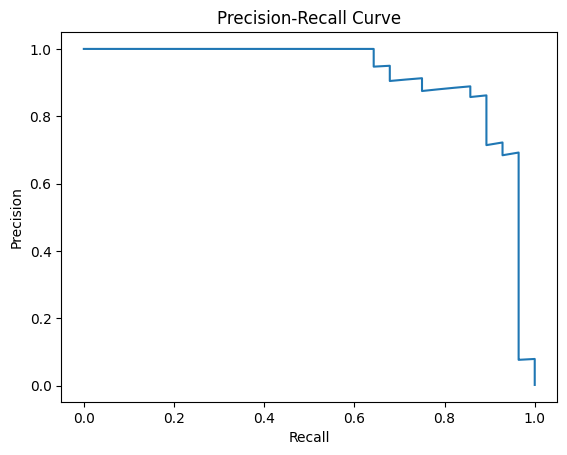

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_val, y_pred_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
threshold = 0.3
y_pred = (y_pred_prob >= threshold).astype(int)

print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

[[12649     4]
 [    3    25]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     12653
         1.0       0.86      0.89      0.88        28

    accuracy                           1.00     12681
   macro avg       0.93      0.95      0.94     12681
weighted avg       1.00      1.00      1.00     12681



In [ ]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importances.head(10)


,Feature,Importance
7,isMerchant,0.252264
13,type_PAYMENT,0.178625
3,newbalanceOrig,0.157162
8,balanceDiffOrig,0.118786
0,step,0.069231
4,oldbalanceDest,0.044621
1,amount,0.036618
14,type_TRANSFER,0.030241
2,oldbalanceOrg,0.021488
10,logAmount,0.020323


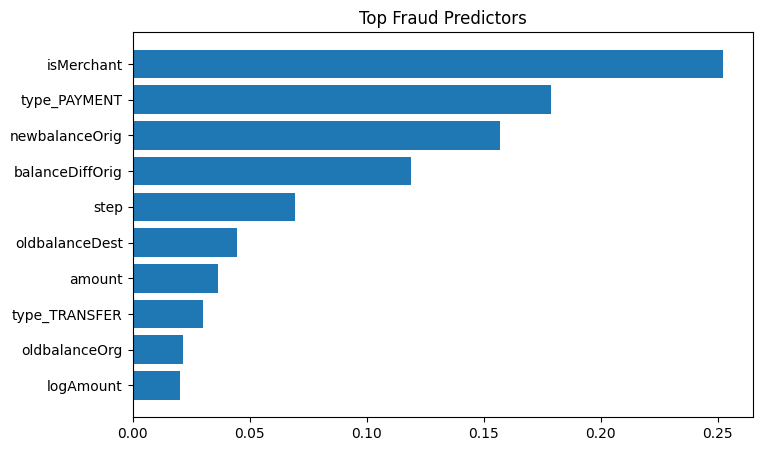

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(importances['Feature'][:10], importances['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top Fraud Predictors")
plt.show()